In [ ]:
from model import *
from utils import *

import matplotlib.pyplot as plt 

ModuleNotFoundError: No module named 'code.model'; 'code' is not a package

In [ ]:
device        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Initiate model with same hyperparameters
osc_branch_net = General_MLP(input_size  = 2, 
                             output_size = 50,
                             depth       = 4, 
                             hidden_size = 32, 
                             act         = nn.Tanh())

osc_trunk_net  = General_MLP(input_size  = 1, 
                             output_size = 50,
                             depth       = 4, 
                             hidden_size = 32, 
                             act         = nn.Tanh())

osc_deepONet   = DeepONet(branch_net = osc_branch_net, 
                          trunk_net  = osc_trunk_net)

# 2. Load the saved weights into the model

state_dict = torch.load("/home/enricp/repos/PINNS/weights/best_model.pth", map_location=device)
osc_deepONet.load_state_dict(state_dict)
osc_deepONet = osc_deepONet.to(device)

# 3. Set to eval mode

osc_deepONet.eval()


DeepONet(
  (branch_net): General_MLP(
    (layers): ModuleList(
      (0): Linear(in_features=2, out_features=32, bias=True)
      (1-2): 2 x Linear(in_features=32, out_features=32, bias=True)
      (3): Linear(in_features=32, out_features=50, bias=True)
    )
    (act): Tanh()
  )
  (trunk_net): General_MLP(
    (layers): ModuleList(
      (0): Linear(in_features=1, out_features=32, bias=True)
      (1-2): 2 x Linear(in_features=32, out_features=32, bias=True)
      (3): Linear(in_features=32, out_features=50, bias=True)
    )
    (act): Tanh()
  )
)

In [ ]:
# Initialize ODE solver 

string_constant = 2
dampening_coeff = 0.1
args1           = [string_constant, dampening_coeff]

osc_sampler     = LatinHypercubeSampler(dimensions = 2, 
                                        lows       = [-1, -1], 
                                        highs      = [1, 1])

osc_object          = harm_osc(args1)
osc_solver          = ODEsolver(osc_object).solve



In [ ]:
# Set sampler and initial conditions

t_eval = np.linspace(0, 10, 100)
t_span = (0, 10)
y0     = osc_sampler(1)[0]


In [ ]:
# Solve using ODE solver 

solver_sol = osc_solver(t_span, 
                        y0, 
                        t_eval=t_eval)

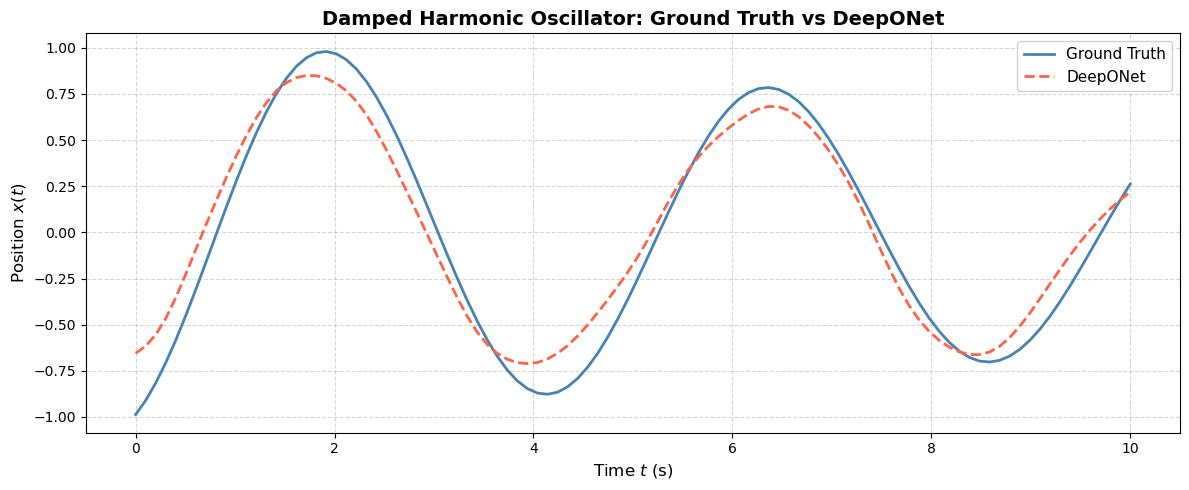

In [ ]:
# Solve using model

with torch.no_grad():
    t_tensor  = torch.tensor(t_eval, dtype=torch.float32).unsqueeze(-1).to(device)  # (1000, 1)
    u0_tensor = torch.tensor(y0,     dtype=torch.float32).unsqueeze(0).to(device)   # (1, 2)
    u0_tensor = u0_tensor.expand(len(t_eval), -1)   # (1000, 2) — broadcast over time steps
    
    model_sol = osc_deepONet(u0_tensor, t_tensor)    # (1000, 2)
    model_sol = model_sol.cpu().numpy()


In [ ]:

plt.figure(figsize=(12, 5))
plt.plot(t_eval, solver_sol.y[0], color="steelblue", lw=2, label="Ground Truth")
plt.plot(t_eval, model_sol[:, 0], color="tomato",    lw=2, label="DeepONet", linestyle="--")
plt.title("Damped Harmonic Oscillator: Ground Truth vs DeepONet", fontsize=14, fontweight="bold")
plt.ylabel("Position $x(t)$", fontsize=12)
plt.xlabel("Time $t$ (s)", fontsize=12)
plt.legend(fontsize=11, framealpha=0.9)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
